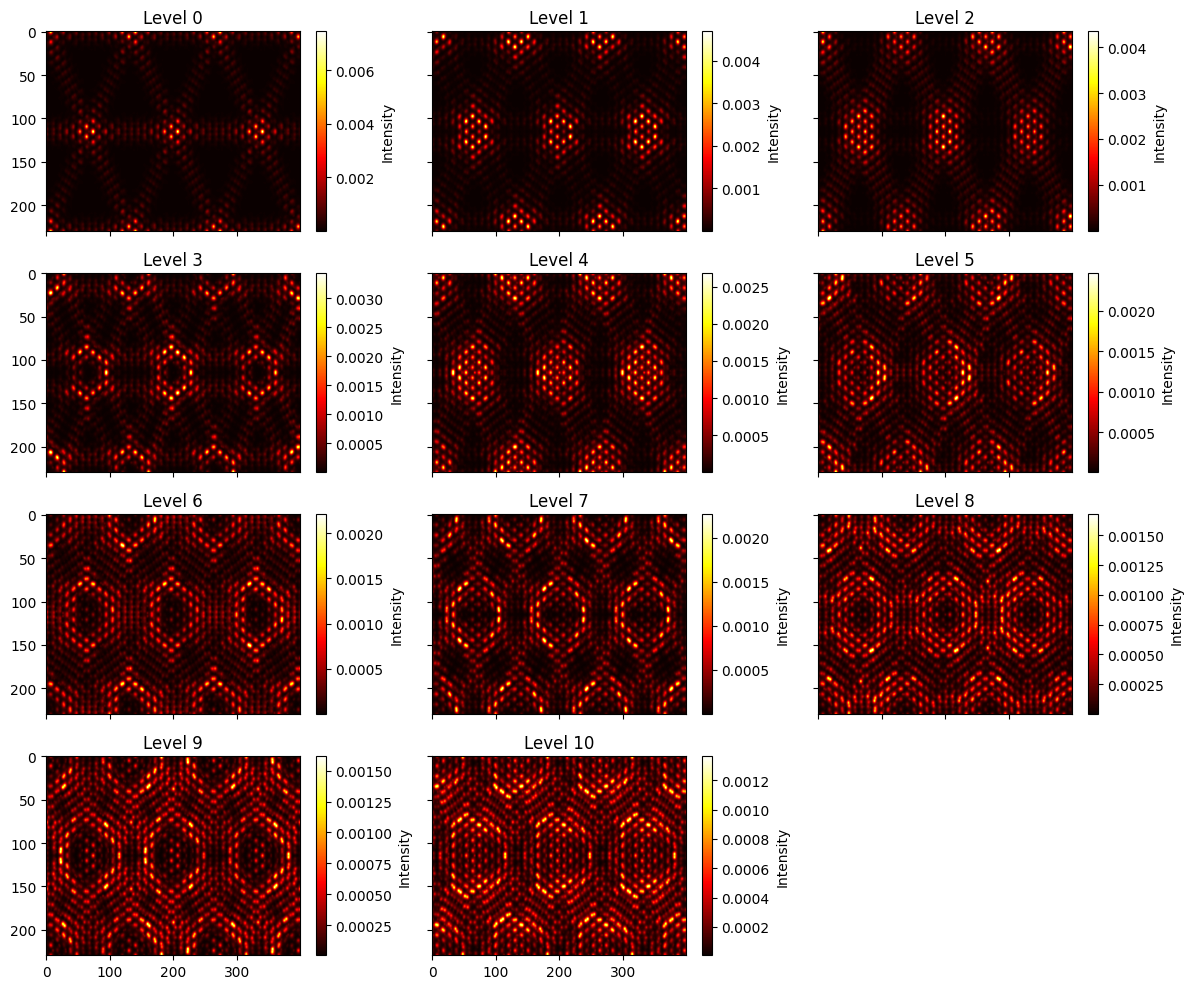

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define number of rows and columns for subplots
rows, cols = 4, 3  # 4x3 grid
num_files = 11  # Total number of text files
data_array = []

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharex=True, sharey=True)

# Flatten the axes array to make it easier to index
axes = axes.flatten()

for i in range(num_files):
    # Load the text file into a numpy array
    data_array.append(np.loadtxt(f"Local_density_of_states_near_band_edge/local_density_of_states_for_level_{i}.txt", delimiter=","))
    
    # Display the heatmap on the correct subplot
    im = axes[i].imshow(data_array[i], cmap="hot", aspect="auto")  

    # Add a colorbar for each subplot
    fig.colorbar(im, ax=axes[i], label="Intensity")
    axes[i].set_title(f"Level {i}")

# Hide any unused subplots (in case we have extra spaces in 4x3 grid)
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()      # Adjust layout to prevent overlapping
#plt.savefig('Heatmaps.png')
plt.show()


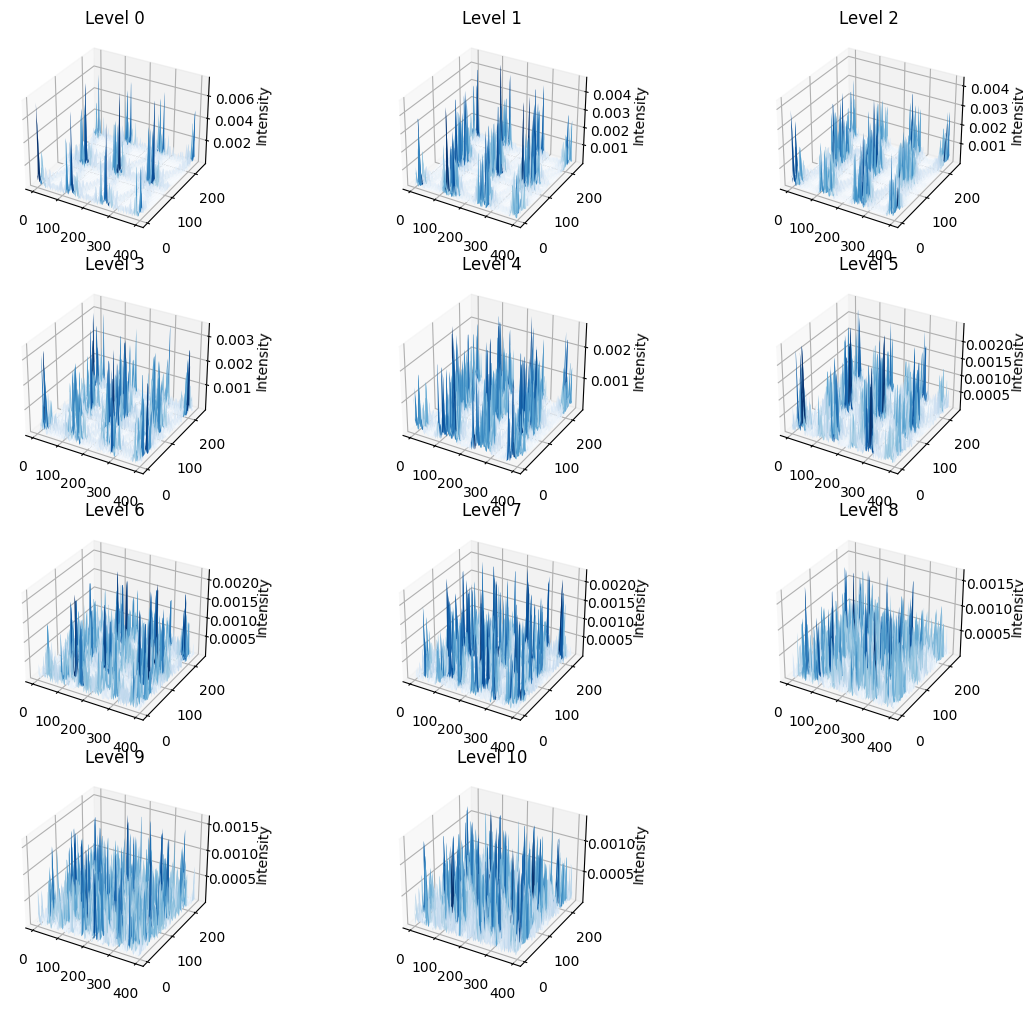

In [2]:
from mpl_toolkits.mplot3d import Axes3D


# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, data in enumerate(data_array):

    # Get x and y grid based on data shape
    x = np.arange(data.shape[1])
    y = np.arange(data.shape[0])
    X, Y = np.meshgrid(x, y)

    # Generate surface plot
    axes[i].plot_surface(X, Y, data, cmap="Blues", edgecolor="none", rcount=50, ccount=50)

    # Set labels and titles
    axes[i].set_title(f"Level {i}")
    axes[i].set_zlabel("Intensity")

# Hide any unused subplots
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()  # Adjust layout before saving
#plt.savefig("surface_plots.png", dpi=300)  # Save the figure
plt.show()


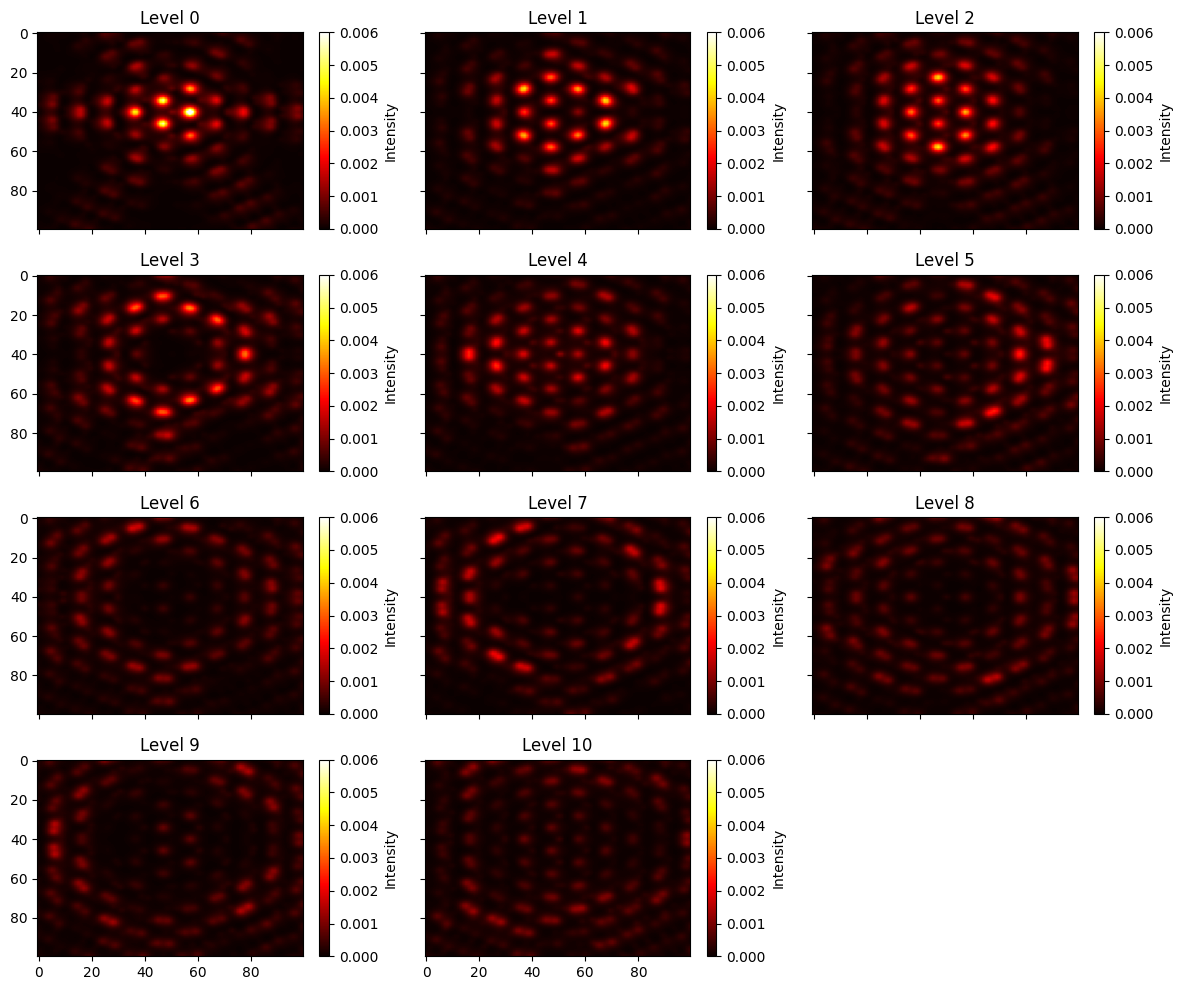

In [3]:
#take one feature, then look how it changes over the different energy levels.

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

feature_arr = []

for i, data in enumerate(data_array):

    # Get x and y grid based on data shape
    x = np.arange(150,250)
    y = np.arange(75, 175)
    X, Y = np.meshgrid(x, y)
    feature_data = data[75:175, 150:250]
    feature_arr.append(feature_data)
    
    # Display the heatmap on the correct subplot
    im = axes[i].imshow(feature_data, cmap="hot", aspect="auto", vmin=0.0, vmax=0.006)  
    fig.colorbar(im, ax=axes[i], label="Intensity")
    axes[i].set_title(f"Level {i}")

# Hide any unused subplots (in case we have extra spaces in 4x3 grid)
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()      # Adjust layout to prevent overlapping
plt.show()


Text(0, 0.5, 'Average intensity')

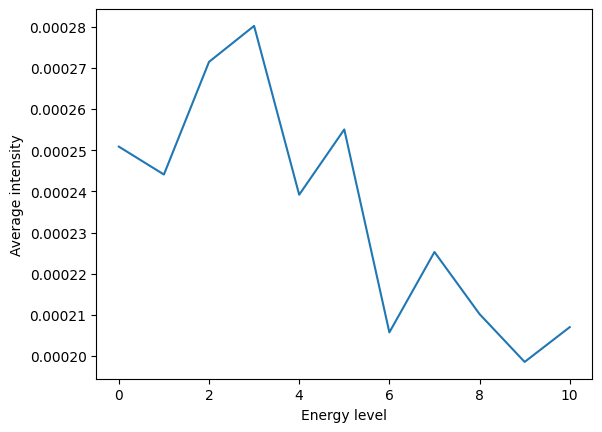

In [ ]:
#I'll plot the average intensity in these regions over different energy levels

mvals = []
Elevel_vals = []
for i, data in enumerate(feature_arr):
    mvals.append(np.mean(data))
    Elevel_vals.append(i)



plt.plot(Elevel_vals, mvals)
plt.xlabel('Energy level')
plt.ylabel('Average intensity')


In [ ]:
#Let's double check the images are normalized.

#I'll plot the average intensity in these regions over different energy levels

mvals = []
Elevel_vals = []
for i, data in enumerate(data_array):
    mvals.append(np.mean(data))
    Elevel_vals.append(i)


print(mvals)
#Good I've confirmed they are normalized

[0.0001935714239130435, 0.0001935753695652174, 0.0001935756304347826, 0.00019357621739130433, 0.00019357525, 0.00019357502173913046, 0.00019357586956521741, 0.00019357609782608698, 0.00019357634782608693, 0.00019357326086956523, 0.00019357561956521738]


The first idea that comes to mind is that the density of states (DOS) is spreaing out at higher energy levels. This agrees with my observation that the DOS near the peak I selected is decreasing; the DOS is getting spread more evenly elsewhere. To quantify this, I'll compute and plot the movement of electrons between successive energy levels.

/tmp/ipykernel_4313/907810486.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout for colorbar


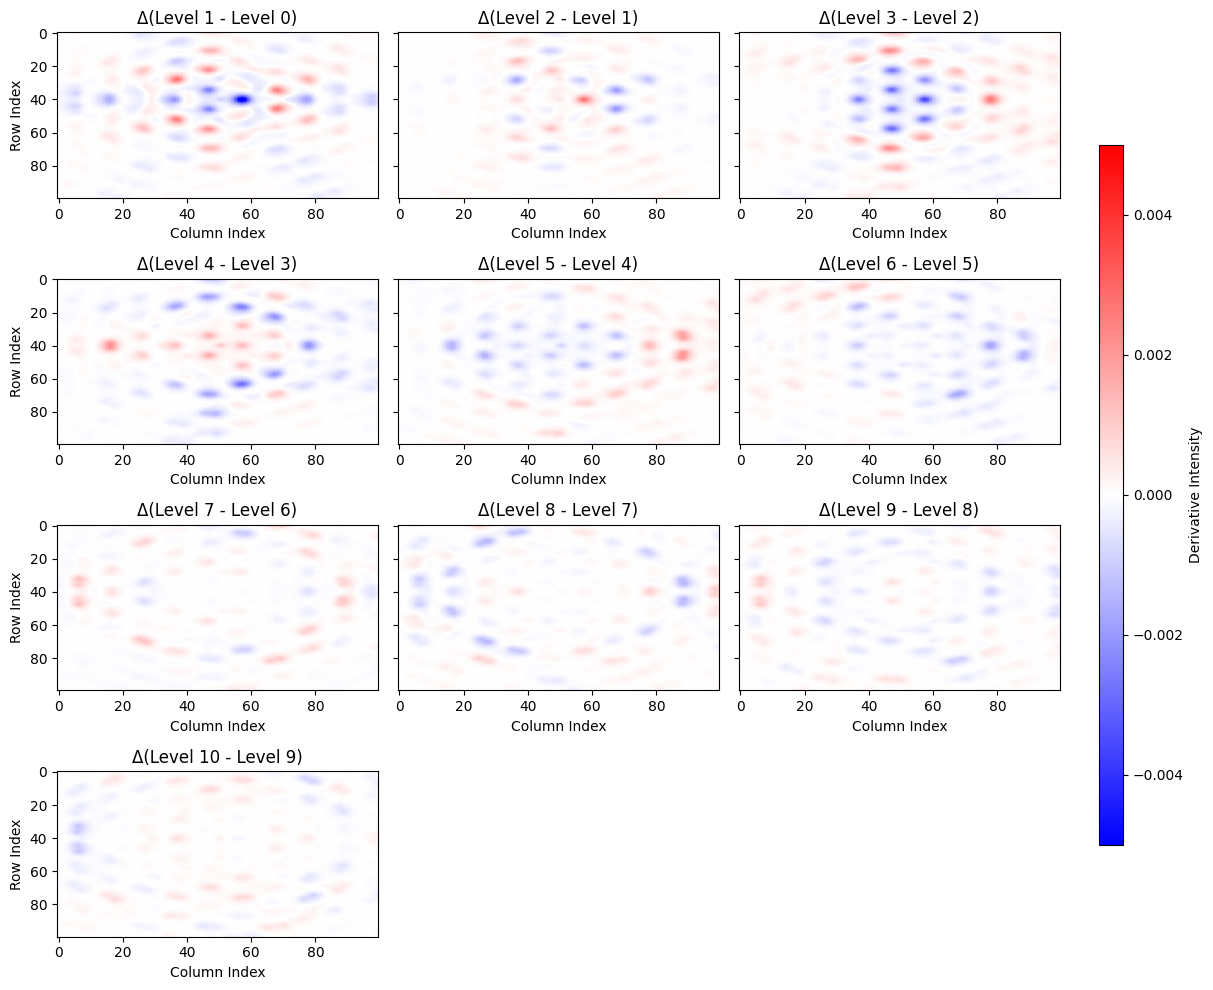

In [ ]:
# Define number of rows and columns for subplots
rows, cols = 4, 3  # 4x3 grid
num_files = 11  # Total number of text files

# Compute frame differences (derivatives)
diff_data = [feature_arr[i+1] - feature_arr[i] for i in range(num_files - 1)]

# Create the figure and axes for derivative plots
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharey=True)
axes = axes.flatten()

for i in range(num_files - 1):  # We have (num_files - 1) derivatives
    im = axes[i].imshow(diff_data[i], cmap="bwr", aspect="auto", vmin=-0.005, vmax=0.005)

    axes[i].set_title(f"Δ(Level {i+1} - Level {i})")
    axes[i].set_xlabel("Column Index")

# Set shared y-axis labels for the first column only
for i in range(0, num_files - 1, cols):
    axes[i].set_ylabel("Row Index")

# Hide unused subplots
for i in range(num_files - 1, rows * cols):
    fig.delaxes(axes[i])

# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Derivative Intensity")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout for colorbar
plt.show()


I don't really see any attention grabbing trends here. 

The last thing I'll try comes from this idea: All of the images look like a superposition of a couple different "travelling waves". I'll take a Fourier transform to see if I can quantify this. (i'll FFT the full DOS plots, not just the feature)

/tmp/ipykernel_4313/3254607056.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout for colorbar


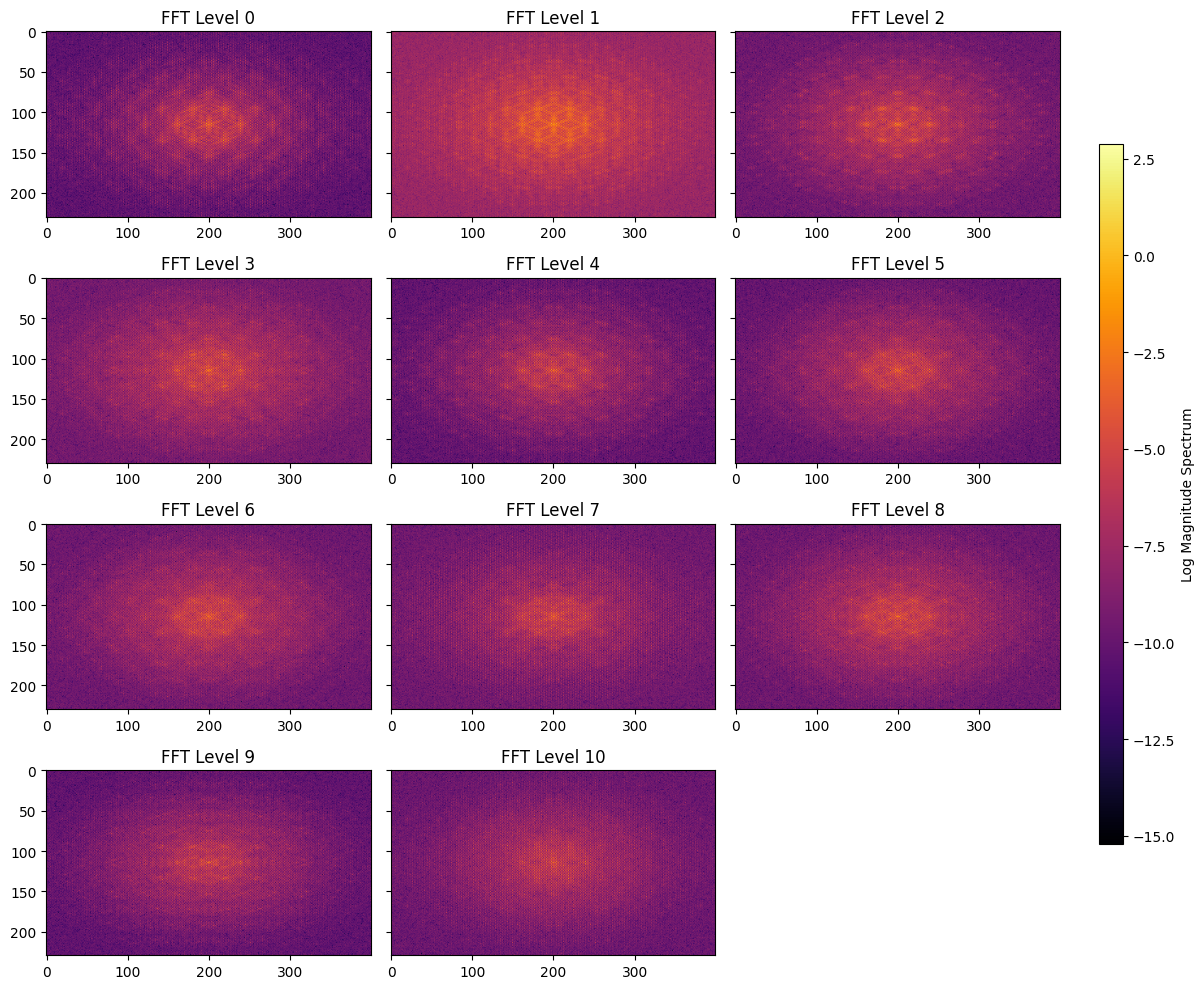

In [6]:


# Define number of rows and columns for subplots
rows, cols = 4, 3  # 4x3 grid
num_files = 11  # Total number of text files

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharey=True)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i in range(num_files):
    # Compute 2D Fourier Transform and shift zero frequency to the center
    fft_data = np.fft.fft2(data_array[i])
    fft_shifted = np.fft.fftshift(fft_data)

    # Compute the magnitude spectrum (log-scaled for visibility)
    magnitude_spectrum = np.log(np.abs(fft_shifted) + 1e-8)  # Avoid log(0)

    # Plot the Fourier Transform result
    im = axes[i].imshow(magnitude_spectrum, cmap="inferno", aspect="auto")

    axes[i].set_title(f"FFT Level {i}")

# Hide unused subplots
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label="Log Magnitude Spectrum")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout for colorbar
plt.show()
